# ARTI406 - Assignment 1: Exploratory Data Analysis (EDA)

## Sleep Health and Lifestyle Dataset

This notebook applies core EDA techniques to the **Sleep Health and Lifestyle Dataset**.  
The goal is to understand the dataset structure, clean selected columns, identify patterns, and visualize useful relationships between sleep, stress, activity, and health indicators.


## Objectives
- Load and inspect the dataset
- Check missing values and duplicates
- Review data types and dataset shape
- Perform basic cleaning
- Generate descriptive statistics
- Conduct univariate, bivariate, and correlation analysis
- Summarize key insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
plt.rcParams['figure.figsize'] = (8, 5)

## Load Dataset

In [3]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Check Missing Values

In [4]:
df.isna()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,False,False,False,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,False,False,False,False,False,False,False,False,False,False,False,False,False
370,False,False,False,False,False,False,False,False,False,False,False,False,False
371,False,False,False,False,False,False,False,False,False,False,False,False,False
372,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isna().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

## Check Duplicate Rows

In [10]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

## Number of Rows and Columns

In [11]:
print("Shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns): (374, 13)
Number of rows: 374
Number of columns: 13


## Data Types Of Columns

In [12]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

## Data Cleaning

In [16]:
import os
os.environ['IPYTHONDIR'] = '/tmp'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df['BMI Category'] = df['BMI Category'].replace({'Normal Weight': 'Normal'})

bp_split = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic BP'] = pd.to_numeric(bp_split[0], errors='coerce')
df['Diastolic BP'] = pd.to_numeric(bp_split[1], errors='coerce')

df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
Systolic BP                  int64
Diastolic BP                 int64
dtype: object

## Descriptive Summary Statistics

In [17]:
df.describe(include='all')

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,374,374.000000,374.000000
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,3,25,NaN,NaN,3,NaN,NaN
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,None,NaN,NaN
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,216,99,NaN,NaN,219,NaN,NaN
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN,128.553476,84.649733
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN,7.748118,6.161611
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN,115.000000,75.000000
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN,125.000000,80.000000
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN,130.000000,85.000000
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN,135.000000,90.000000


## Univariate Analysis

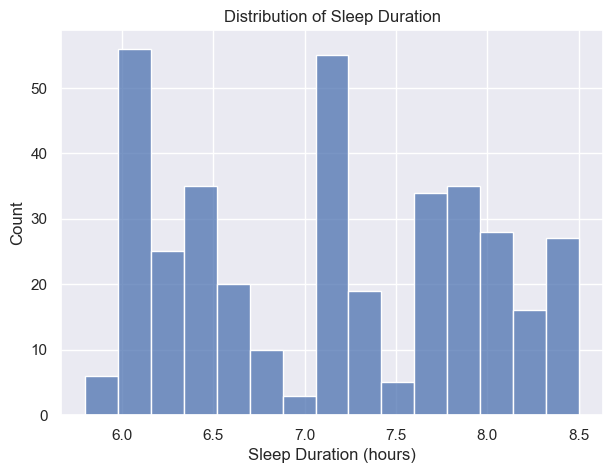

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(df['Sleep Duration'], bins=15)
plt.title('Distribution of Sleep Duration')
plt.xlabel('Sleep Duration (hours)')
plt.show()

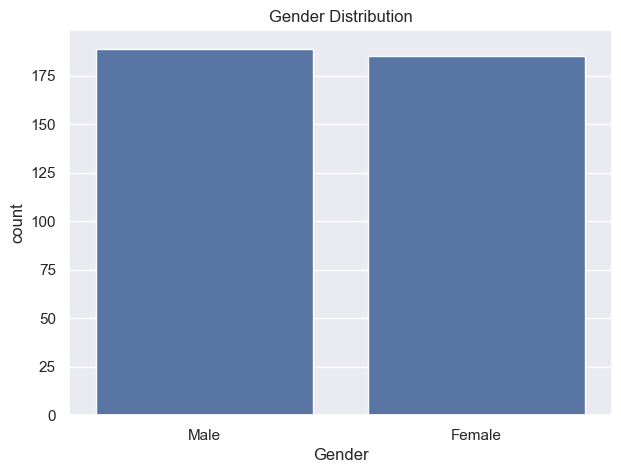

In [19]:
plt.figure(figsize=(7,5))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

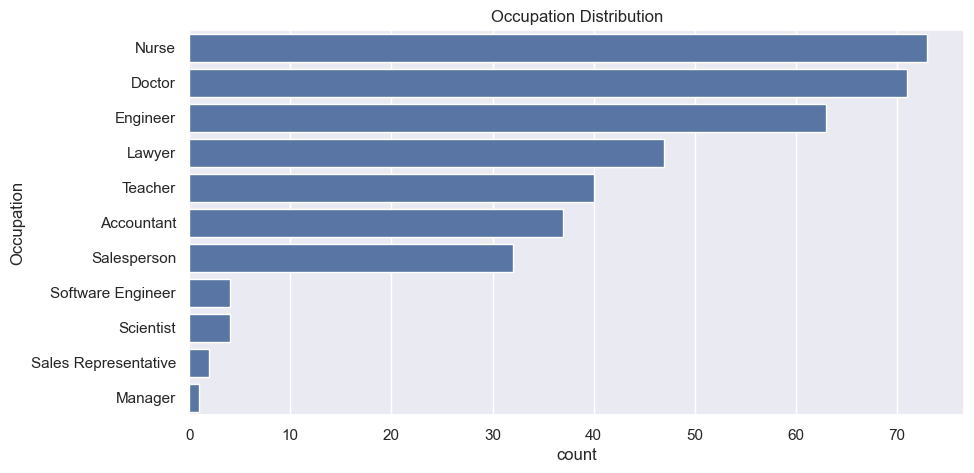

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(y='Occupation', data=df, order=df['Occupation'].value_counts().index)
plt.title('Occupation Distribution')
plt.show()

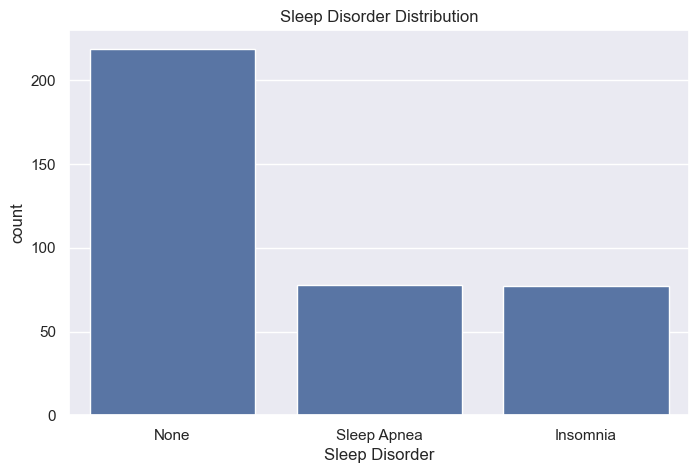

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sleep Disorder', data=df, order=df['Sleep Disorder'].value_counts().index)
plt.title('Sleep Disorder Distribution')
plt.show()

## Bivariate Analysis

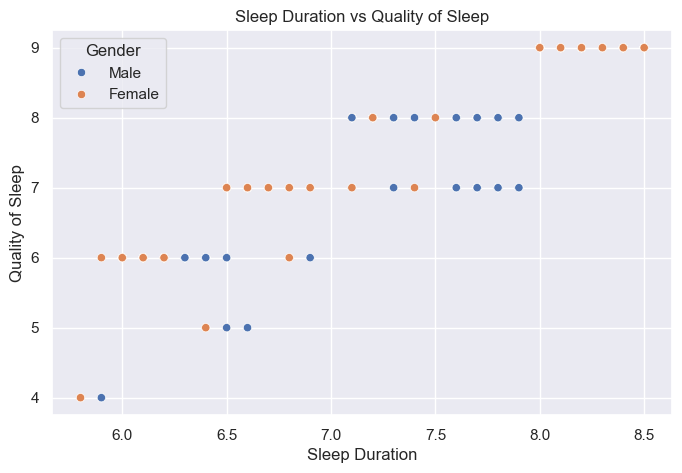

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sleep Duration', y='Quality of Sleep', hue='Gender', data=df)
plt.title('Sleep Duration vs Quality of Sleep')
plt.show()

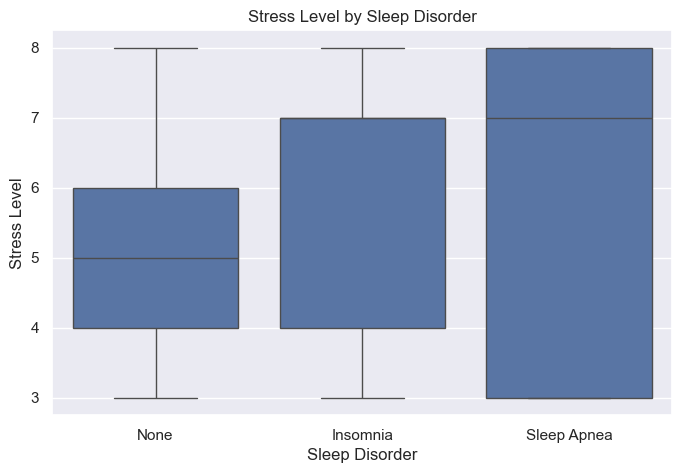

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Sleep Disorder', y='Stress Level', data=df, order=['None', 'Insomnia', 'Sleep Apnea'])
plt.title('Stress Level by Sleep Disorder')
plt.show()

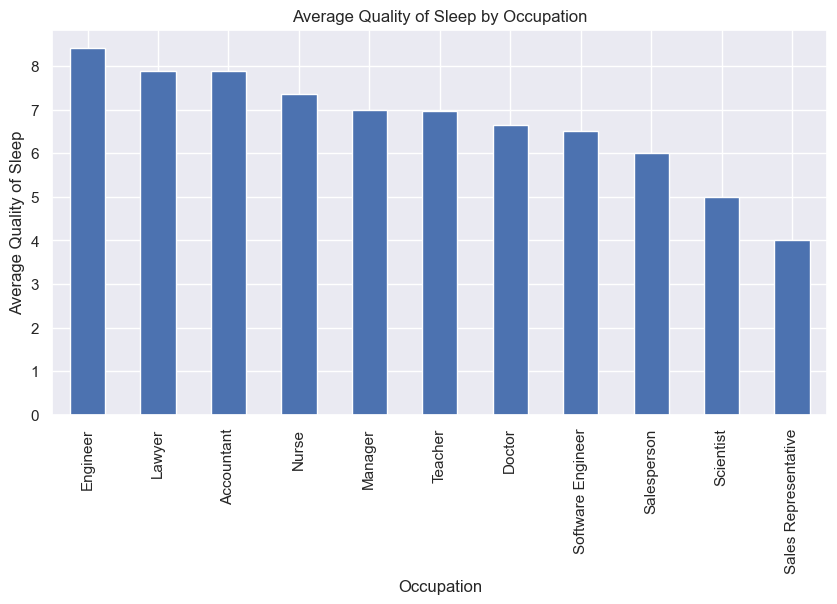

Occupation
Engineer                8.412698
Lawyer                  7.893617
Accountant              7.891892
Nurse                   7.369863
Manager                 7.000000
Teacher                 6.975000
Doctor                  6.647887
Software Engineer       6.500000
Salesperson             6.000000
Scientist               5.000000
Sales Representative    4.000000
Name: Quality of Sleep, dtype: float64

In [24]:
occupation_sleep = df.groupby('Occupation')['Quality of Sleep'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
occupation_sleep.plot(kind='bar')
plt.title('Average Quality of Sleep by Occupation')
plt.ylabel('Average Quality of Sleep')
plt.show()

occupation_sleep

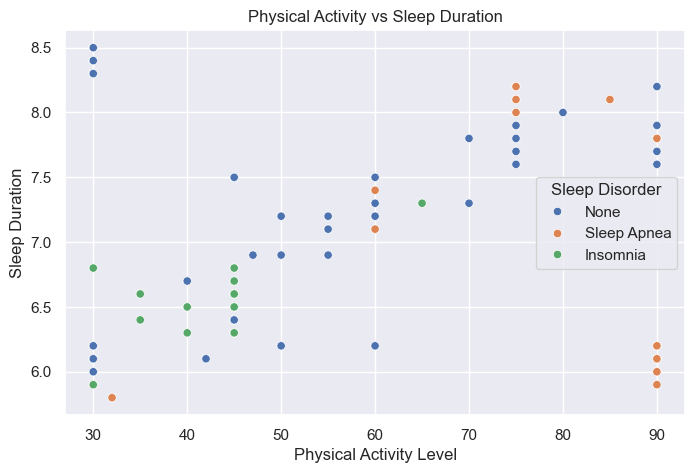

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Physical Activity Level', y='Sleep Duration', hue='Sleep Disorder', data=df)
plt.title('Physical Activity vs Sleep Duration')
plt.show()

## Correlation Matrix

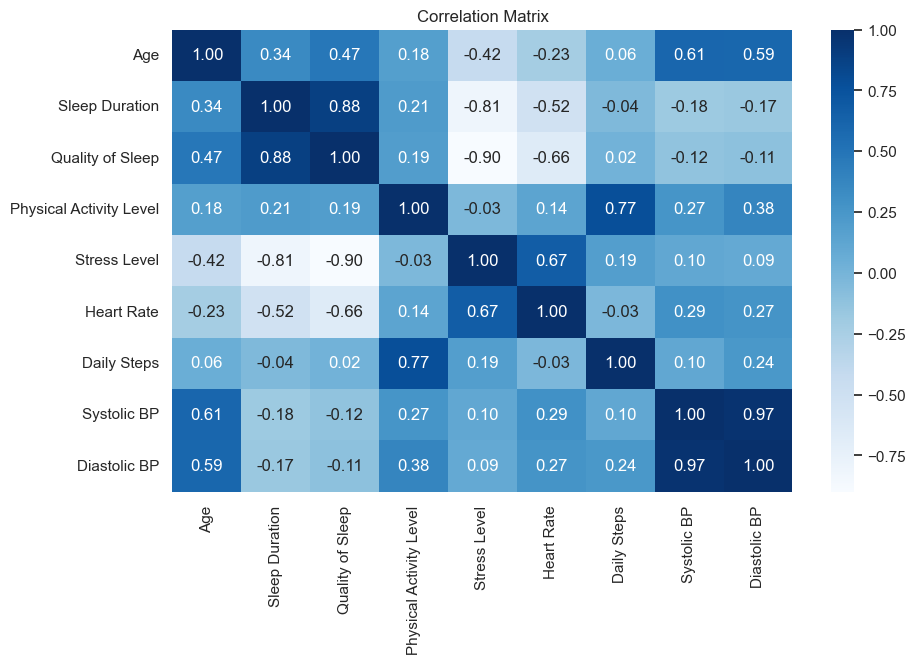

In [26]:
numeric_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Additional Summary Tables

In [27]:
df.groupby('Gender')[['Sleep Duration', 'Quality of Sleep', 'Stress Level']].mean()

,Sleep Duration,Quality of Sleep,Stress Level
Gender,,,
Female,7.229730,7.664865,4.675676
Male,7.036508,6.968254,6.079365


In [28]:
df.groupby('Sleep Disorder')[['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Heart Rate']].mean()

,Sleep Duration,Quality of Sleep,Stress Level,Heart Rate
Sleep Disorder,,,,
Insomnia,6.589610,6.532468,5.870130,70.467532
None,7.358447,7.625571,5.114155,69.018265
Sleep Apnea,7.032051,7.205128,5.666667,73.089744


## Key Insights

1. **Sleep duration and sleep quality move together strongly.** People who sleep longer generally report better sleep quality.
2. **Stress level has a strong negative relationship with sleep.** Higher stress is associated with lower sleep duration and lower sleep quality.
3. **Participants with insomnia show weaker sleep outcomes.** On average, they have shorter sleep duration and lower sleep quality than participants with no disorder.
4. **Heart rate tends to increase when stress increases and sleep quality decreases.**
5. **Occupation appears to matter.** Some occupations show better average sleep quality than others, which suggests lifestyle or work pressure may influence sleep patterns.
